In [20]:
# Autoreload ensures that your python-files stay up-to-date: https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

# Move back to the root directory
%cd ..

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/workspaces


/opt/venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [28]:
# Install all dependencies from pyproject.toml
!cd /workspaces/updated-minifigures-webshop-2026-LorenzSF && uv sync --all-groups

Resolved 295 packages in 104ms
   Building minifigures-app @ file:///workspaces/updated-minifigures-webshop-202
   Building minifigures-app @ file:///workspaces/updated-minifigures-webshop-202
   Building minifigures-app @ file:///workspaces/updated-minifigures-webshop-202
   Building minifigures-app @ file:///workspaces/updated-minifigures-webshop-202
   Building minifigures-app @ file:///workspaces/updated-minifigures-webshop-202
      Built minifigures-app @ file:///workspaces/updated-minifigures-webshop-202
Prepared 1 package in 968ms                                              
Uninstalled 1 package in 2ms
Installed 1 package in 0.84ms (from file:///workspaces/updat
 ~ minifigures-app==0.0.0 (from file:///workspaces/updated-minifigures-webshop-2026-LorenzSF)


DONT FORGET TO RESTART THE KERNEL OF THE NOTEBOOK AFTER!

In [ ]:
# Import necessary libraries
import csv
import json
import random
import re
from collections import Counter
from pathlib import Path
from random import choice, randint

import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tqdm import tqdm

# Data Exploration

## Quick data analysis - FastDup

Luckily, there exist some good libraries out there that do much of the heavy lifting for you and allow you to very quickly get insights in your dataset in a few lines of code. One of these is [FastDup](https://github.com/visual-layer/fastdup). Full documentation [here](https://visual-layer.github.io/fastdup/).

In [3]:
from shutil import rmtree

import fastdup

In [4]:
# Remove if already exists
if Path("fastdup/run").is_dir():
    rmtree("fastdup/run")

fd = fastdup.create(work_dir="fastdup/run", input_dir="data/data/minifigures")
fd.run(nearest_neighbors_k=5, ccthreshold=0.96)

FastDup Software, (C) copyright 2022 Dr. Amir Alush and Dr. Danny Bickson.
2026-02-25 12:30:11 [INFO] Going to loop over dir data/data/minifigures
2026-02-25 12:30:11 [INFO] Found total 6805 images to run on, 6805 train, 0 test, name list 6805, counter 6805 
2026-02-25 12:30:11 [WARNING] Failed to read valid png header on file data/data/minifigures/._hp199.png
2026-02-25 12:30:11 [WARNING] Failed to read valid png header on file data/data/minifigures/._njo309.png
2026-02-25 12:30:11 [WARNING] Failed to read valid png header on file data/data/minifigures/._sw0029.png
2026-02-25 12:30:11 [WARNING] Failed to read valid png header on file data/data/minifigures/._sw0838.png
2026-02-25 12:31:45 [INFO] Found total 6805 images to run ontimated: 0 Minutes
Finished histogram 4.057
Finished bucket sort 4.090
2026-02-25 12:31:47 [INFO] 1600) Finished write_index() NN model
2026-02-25 12:31:47 [INFO] Stored nn model index file fastdup/run/nnf.index
2026-02-25 12:31:48 [INFO] Total time took 96650 m

/opt/venv/lib/python3.10/site-packages/fastdup/fastdup_controller.py:1133: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self._df_annot[FD.ANNOT_FILENAME].fillna(self._df_annot[FD.ANNOT_FILENAME + '_map'], inplace=True)



 ########################################################################################

Dataset Analysis Summary: 

    Dataset contains 6805 images
    Valid images are 99.94% (6,801) of the data, invalid are 0.06% (4) of the data
    For a detailed analysis, use `.invalid_instances()`.

    Similarity:  16.56% (1,127) belong to 28 similarity clusters (components).
    83.44% (5,678) images do not belong to any similarity cluster.
    Largest cluster has 260 (3.82%) images.
    For a detailed analysis, use `.connected_components()`
(similarity threshold used is 0.9, connected component threshold used is 0.96).

    Outliers: 7.38% (502) of images are possible outliers, and fall in the bottom 5.00% of similarity values.
    For a detailed list of outliers, use `.outliers()`.

########################################################################################
Would you like to see awesome visualizations for some of the most popular academic datasets?
Click here to see and learn

0

In [5]:
# Create visual gallery of duplicates
fd.vis.duplicates_gallery(num_images=15)

# Create visual gallery of anomalies
fd.vis.outliers_gallery(num_images=15)

# Create visual gallery of clusters
fd.vis.component_gallery(num_images=15)

# Create visual gallery of blur
fd.vis.stats_gallery(metric="blur", num_images=15)

# Create visual gallery of similar images
fd.vis.similarity_gallery(num_images=15)


# View the galleries by opening the generated HTML files in the browser (in fastdup/run/galleries)

Generating gallery:   0%|          | 0/15 [00:00<?, ?it/s]

Stored similarity visual view in  fastdup/run/galleries/duplicates.html
########################################################################################
Would you like to see awesome visualizations for some of the most popular academic datasets?
Click here to see and learn more: https://app.visual-layer.com/vl-datasets?utm_source=fastdup
########################################################################################


[ WARN:0@100.545] global loadsave.cpp:268 findDecoder imread_('/opt/venv/lib/python3.10/site-packages/fastdup/assets/logo/logo.png'): can't open/read file: check file path/integrity


Generating gallery:   0%|          | 0/15 [00:00<?, ?it/s]

[ WARN:0@100.753] global loadsave.cpp:268 findDecoder imread_('/opt/venv/lib/python3.10/site-packages/fastdup/assets/logo/logo.png'): can't open/read file: check file path/integrity


...

Stored blur visual view in  fastdup/run/galleries/blur.html
########################################################################################
Would you like to see awesome visualizations for some of the most popular academic datasets?
Click here to see and learn more: https://app.visual-layer.com/vl-datasets?utm_source=fastdup
########################################################################################


Generating gallery:   0%|          | 0/15 [00:00<?, ?it/s]

Stored similar images visual view in  fastdup/run/galleries/similarity.html
########################################################################################
Would you like to see awesome visualizations for some of the most popular academic datasets?
Click here to see and learn more: https://app.visual-layer.com/vl-datasets?utm_source=fastdup
########################################################################################


[ WARN:0@103.628] global loadsave.cpp:268 findDecoder imread_('/opt/venv/lib/python3.10/site-packages/fastdup/assets/logo/logo.png'): can't open/read file: check file path/integrity


,from,to,distance
1343,data/data/minifigures/div001a.png,"[data/data/minifigures/ext001.png, data/data/minifigures/njo702.png]","[0.900002, 0.90183]"
1376,data/data/minifigures/ext001.png,"[data/data/minifigures/div001a.png, data/data/minifigures/ext002.png, data/data/minifigures/ext014.png, data/data/minifigures/ext005.png, data/data/minifigures/ext018.png]","[0.900002, 0.9025, 0.90606, 0.907737, 0.925274]"
3095,data/data/minifigures/sh606.png,"[data/data/minifigures/sh596.png, data/data/minifigures/hp311.png, data/data/minifigures/hp188.png, data/data/minifigures/col333.png, data/data/minifigures/jw027.png]","[0.900004, 0.90156, 0.90607, 0.912602, 0.934954]"
3090,data/data/minifigures/sh596.png,"[data/data/minifigures/sh606.png, data/data/minifigures/sh636.png]","[0.900004, 0.937724]"
423,data/data/minifigures/col249.png,"[data/data/minifigures/tlm196.png, data/data/minifigures/tlm072.png, data/data/minifigures/tlm087.png, data/data/minifigures/cty1305.png]","[0.900011, 0.902464, 0.904061, 0.904787]"
...,...,...,...
429,data/data/minifigures/col279.png,[data/data/minifigures/cty0384.png],[0.999388]
4162,data/data/minifigures/ww009b.png,[data/data/minifigures/ww009.png],[1.0]
68,data/data/minifigures/adv053.png,[data/data/minifigures/adv053b.png],[1.0]
69,data/data/minifigures/adv053b.png,[data/data/minifigures/adv053.png],[1.0]


## Manual exploration

In a second iteration, we'll go manually over the data to generate some deeper insights.

### 1. Visualise the data

Visualise a random subset of images from our dataset.

In [6]:
# Load in all the data paths using pathlib
files = sorted((Path.cwd() / "data/data/minifigures").glob("*.png"))
n_files = len(files)
n_files

6805

In [7]:
# Remove the samples with a faulty name
files = [path for path in files if path.name[0] != "."]
n_files = len(files)
n_files

6801

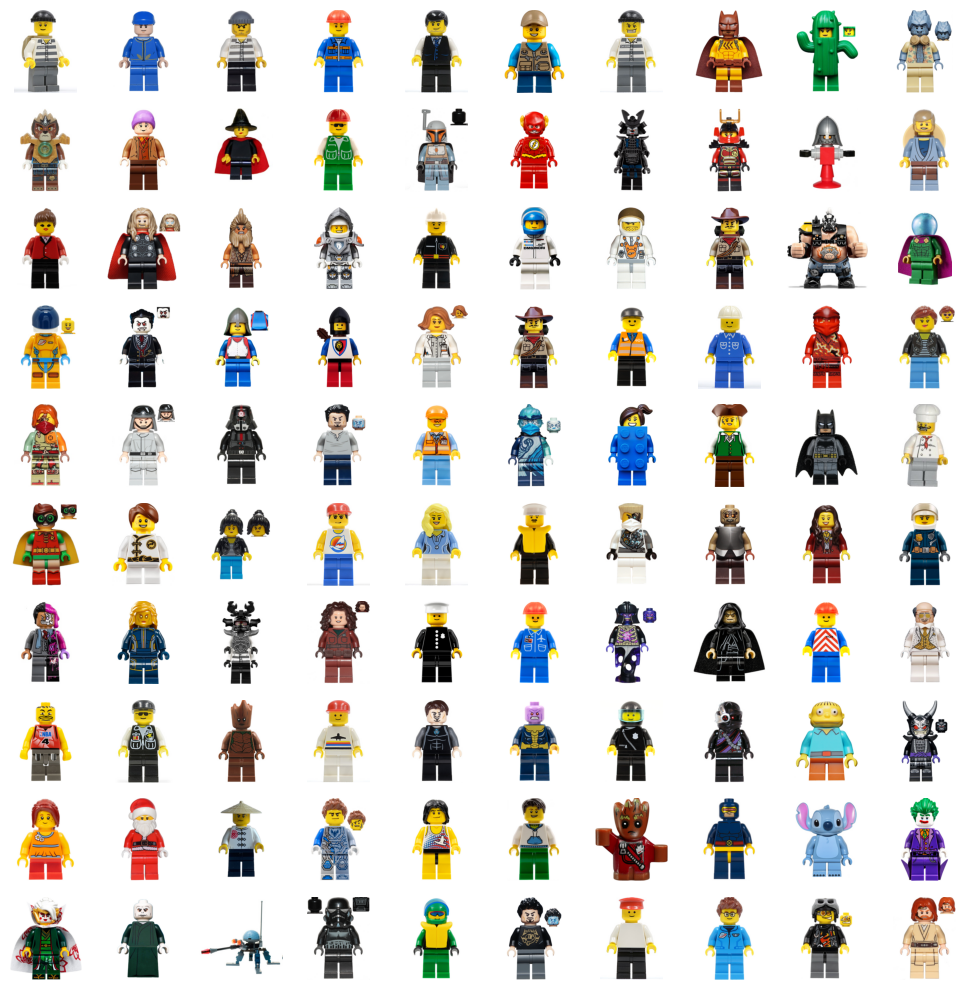

In [8]:
# Visualise 100 images at random
_, axs = plt.subplots(10, 10, figsize=(10, 10))
for i in range(10 * 10):
    axs[i % 10, i // 10].imshow(Image.open(files[randint(0, n_files - 1)]))
_ = [ax.set_axis_off() for ax in axs.ravel()]
plt.tight_layout()
plt.show()

### 2. Dataset distribution

Next, when looking into the images' names, we notice that some of them have a prefix, indicating from which dataset they are. Let's extract this prefix and see what type of minifigures we can expect the most. 

In [9]:
# For most samples, there's a dataset prefix
files[200:220]

[PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air046a.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air048.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air050.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air051.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air052.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air053.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air054.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/air055.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/minifigures/airdg001.png'),
 PosixPath('/workspaces/updated-minifigures-webshop-2026-LorenzSF/data/data/min

In [10]:
# Create a function to extract the prefix from a path
def extract_prefix(path: Path) -> str | None:
    """Extract the prefix from the Path."""
    name = path.with_suffix("").name
    prefix = re.search("^[a-z]+", name)
    if prefix:
        return prefix.group(0)
    return None


extract_prefix(files[123])

'ac'

In [11]:
# Generate all the prefixes
prefixes = [extract_prefix(p) for p in tqdm(files)]

# Show to top N prefixes
counts = Counter(prefixes)
if None in counts:
    del counts[None]

top_n = 10
prefixes_ = sorted(counts.items(), key=lambda x: x[1], reverse=True)
prefixes_[:top_n]

100%|██████████| 6801/6801 [00:00<00:00, 88194.80it/s]


[('cty', 898),
 ('sw', 823),
 ('sh', 714),
 ('njo', 660),
 ('cas', 267),
 ('twn', 261),
 ('col', 232),
 ('hol', 170),
 ('hp', 147),
 ('pi', 117)]

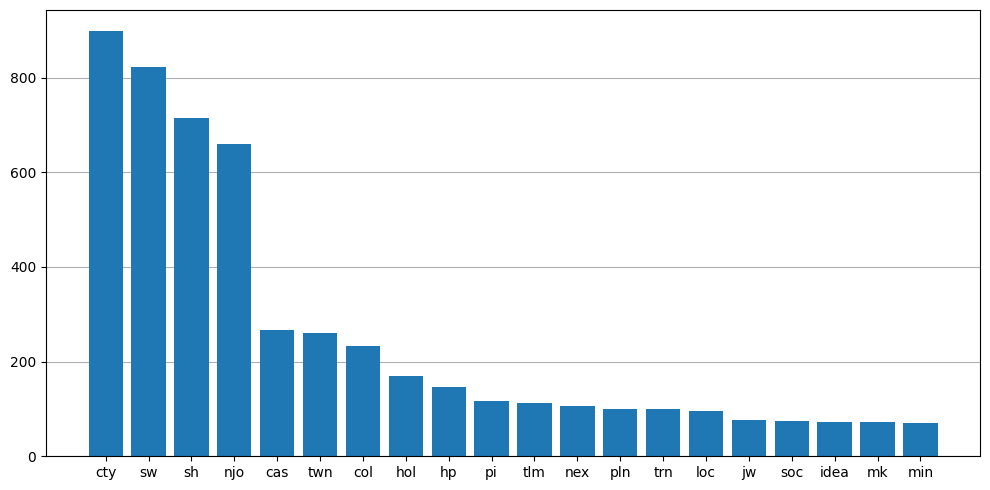

In [12]:
# Visualise dataset distribution
top_n = 20

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), [v for _, v in prefixes_[:top_n]], zorder=2)
plt.xticks(range(top_n), [k for k, _ in prefixes_[:top_n]])
plt.tight_layout()
plt.grid(axis="y")
plt.show()

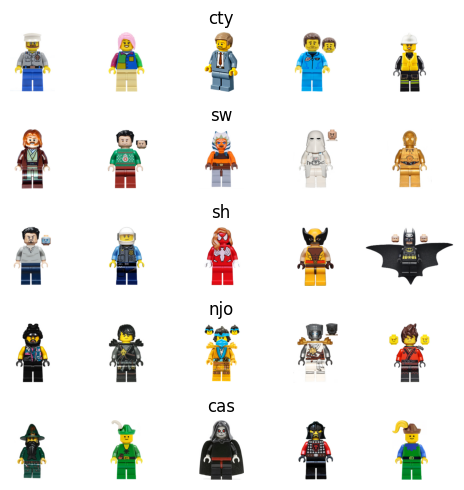

In [13]:
# Show examples for each top_n classes
top_n, n_col = 5, 5

_, axs = plt.subplots(top_n, n_col, figsize=(n_col, top_n))
for i in range(top_n):
    p, n = prefixes_[i]
    selection = [path for path, prefix in zip(files, prefixes) if prefix == p]
    for j in range(n_col):
        axs[i, j].imshow(Image.open(selection[randint(0, len(selection) - 1)]))
        if j == (n_col // 2):
            axs[i, j].set_title(p)
_ = [ax.set_axis_off() for ax in axs.ravel()]
plt.tight_layout()
plt.show()

### 3. Sizes

Images have different sizes, let's investigate what the size distribution is of our dataset. This is interesting to keep in mind for later, when we start building a Machine Learning model.

In [14]:
# Get the image's shapes
shapes = [Image.open(path).size for path in tqdm(files)]
x, y = zip(*shapes)

100%|██████████| 6801/6801 [00:00<00:00, 16580.96it/s]


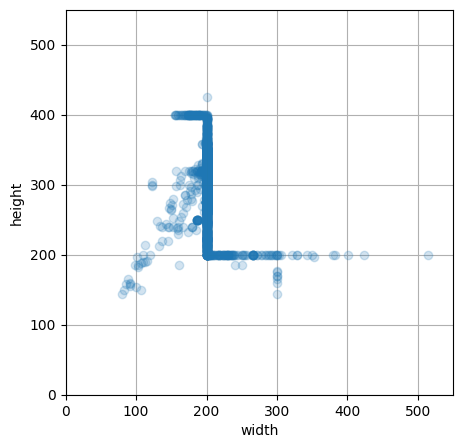

In [15]:
# Visualise the shapes
plt.figure(figsize=(5, 5))
plt.scatter(x, y, alpha=0.2, zorder=2)
plt.xlabel("width")
plt.ylabel("height")
plt.ylim(0, 550)
plt.xlim(0, 550)
plt.grid()
plt.show()

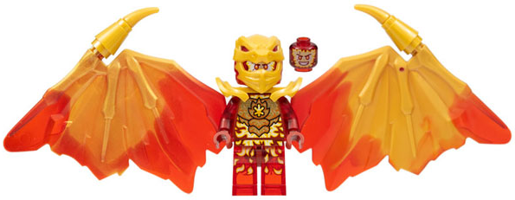

In [16]:
# Who's the wide one?
idx = [v > 500 for v in x]
Image.open(files[idx.index(True)])

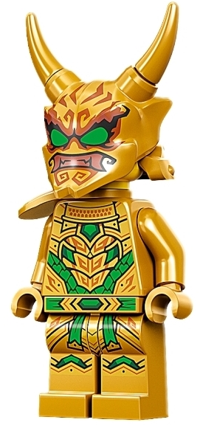

In [17]:
# Who's the tall one?
idx = [v > 420 for v in y]
Image.open(files[idx.index(True)])

### 4. Labels

Next to the images themselves, we also have a `dataset.json` that contains the target labels of a few samples in our dataset. Let's have a look how this looks like!

This will show us that we're working with a rather imbalanced dataset, but that there are also already several samples for each individual label.

In [18]:
# Open up the dataset, show how many labels there are, and which unique labels exist
with open("data/data/dataset.json") as f:
    dataset = json.load(f)
labels = sorted({x for y in dataset.values() for x in y})
len(dataset), labels

(136,
 ['alien',
  'angry',
  'cape',
  'facial hair',
  'glasses',
  'happy',
  'hat',
  'helmet',
  'human',
  'robot'])

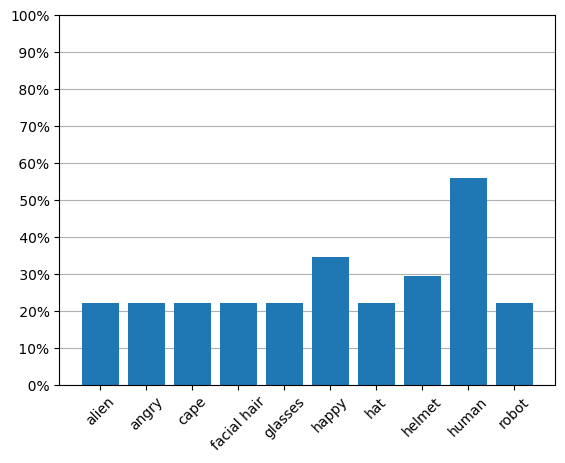

In [19]:
# Plot the label ratios
counts = Counter()
for v in dataset.values():
    counts.update(v)

plt.figure()
plt.bar(labels, [counts[l] / len(dataset) for l in labels], zorder=2)
plt.xticks(labels, rotation=45)
plt.yticks([i / 10 for i in range(11)], [f"{10 * i:3d}%" for i in range(11)])
plt.grid(axis="y")
plt.show()